<a href="https://colab.research.google.com/github/Preet-Kanwal-Singh/Machine-Learning-Projects/blob/main/MentalHealth/MentalHealthAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install unidecode
!pip install contractions
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.8 MB/s eta 0:00:00


In [6]:
import pandas as pd

import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

import re
import string

from unidecode import unidecode
import contractions

df = pd.read_csv('/content/Combined Data.csv')
print(df.shape)
print(df.columns)
print(df.isnull().sum())
df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(53043, 3)
Index(['Unnamed: 0', 'statement', 'status'], dtype='object')
Unnamed: 0      0
statement     362
status          0
dtype: int64


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [7]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

df['statement'] = df['statement'].astype(str)  # ensure string
df['statement'] = df['statement'].replace('nan', pd.NA)  # if string 'nan' exists
df = df.dropna(subset=['statement'])
df = df[df['statement'].str.strip() != '']   # remove empty strings

print("After removing missing:", df.shape)


After removing missing: (52681, 2)


In [8]:
before = len(df)
df = df.drop_duplicates(subset=['statement', 'status'], keep='first')
after = len(df)
print(f"Removed {before-after} duplicate rows")


Removed 1588 duplicate rows


In [9]:
# class distribution
counts = df['status'].value_counts()
print(counts)

min_samples = 50
rare = counts[counts < min_samples].index.tolist()
print("Rare labels:", rare)


status
Normal                  16040
Depression              15094
Suicidal                10644
Anxiety                  3623
Bipolar                  2501
Stress                   2296
Personality disorder      895
Name: count, dtype: int64
Rare labels: []


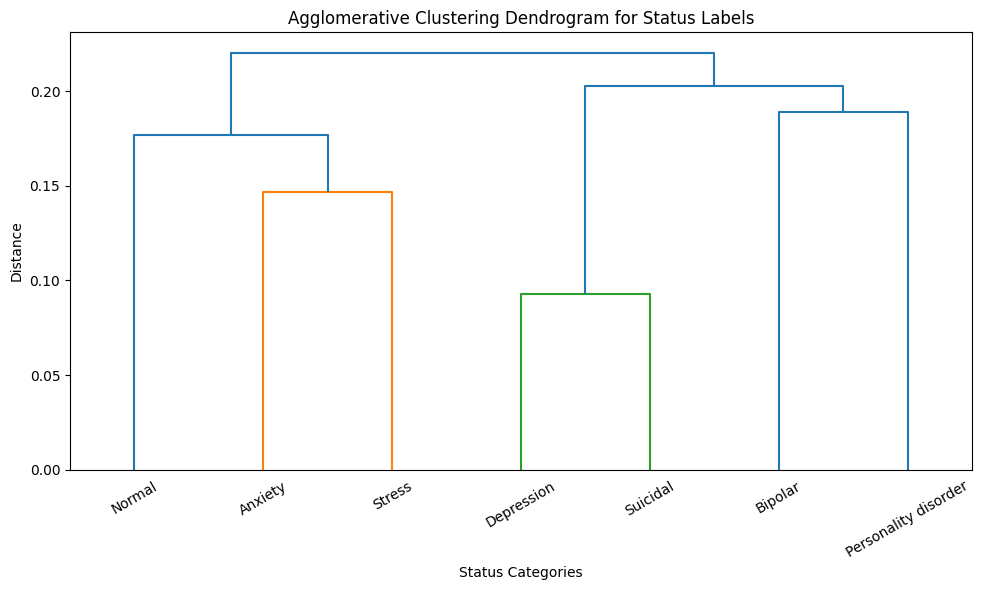

In [10]:
texts = df['statement'].astype(str).tolist()
labels = df['status'].astype(str).values
label_names = sorted(df['status'].unique())

tfidf = TfidfVectorizer(max_features=2000, stop_words='english')
X = tfidf.fit_transform(texts)

centroids = []
for lab in label_names:
    mask = (labels == lab)
    centroid = X[mask].mean(axis=0)
    centroids.append(np.asarray(centroid).ravel())
centroids = np.vstack(centroids)

Z = linkage(centroids, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=label_names, leaf_rotation=30, leaf_font_size=10)
plt.title("Agglomerative Clustering Dendrogram for Status Labels")
plt.xlabel("Status Categories")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [11]:
def clean_text(text, min_len=3):
    if not isinstance(text, str):
        return ""
    # 1. normalize unicode chars
    text = unidecode(text)
    # 2. expand contractions ("don't" -> "do not")
    text = contractions.fix(text)
    # 3. lower
    text = text.lower()
    # 4. remove urls, emails, html tags
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', ' ', text)
    # 5. remove punctuation and numbers (keeping spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 6. collapse repeated characters (e.g., coooool -> cool)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # 7. collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # 8. optionally drop very short tokens / statements
    if len(text.split()) < min_len:
        return ""
    return text

# Apply
df['cleaned'] = df['statement'].astype(str).apply(clean_text)
# drop rows turned empty after cleaning
df = df[df['cleaned'] != ""]
print("After cleaning:", df.shape)
df[['statement','cleaned','status']].head()

# Download the missing 'punkt_tab' resource
nltk.download('punkt_tab')

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_clean(text):
    toks = word_tokenize(text)
    toks = [t for t in toks if t.isalpha() and t not in stop]  # remove stopwords & non-alpha
    toks = [lemmatizer.lemmatize(t) for t in toks]
    return " ".join(toks)

df['clean_tokens'] = df['cleaned'].apply(tokenize_clean)
# drop empty after tokenization
df = df[df['clean_tokens'].str.strip() != ""]
print("After tokenizing & lemmatizing:", df.shape)
df[['cleaned','clean_tokens']].head()

After cleaning: (50339, 3)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


After tokenizing & lemmatizing: (50263, 4)


,cleaned,clean_tokens
0,oh my gosh,oh gosh
1,trouble sleeping confused mind restless heart ...,trouble sleeping confused mind restless heart ...
2,all wrong back off dear forward doubt stay in ...,wrong back dear forward doubt stay restless re...
3,i have shifted my focus to something else but ...,shifted focus something else still worried
4,i am restless and restless it is been a month ...,restless restless month boy mean


In [12]:
df.loc[:, 'n_tokens'] = df['clean_tokens'].str.split().apply(len)

print(df['n_tokens'].describe())

# drop too short or too long samples
df = df[(df['n_tokens'] >= 3) & (df['n_tokens'] <= 200)]

print("After length filtering:", df.shape)


count    50263.000000
mean        50.834471
std         72.368541
min          1.000000
25%          8.000000
50%         28.000000
75%         66.000000
max       2520.000000
Name: n_tokens, dtype: float64
After length filtering: (46014, 5)


In [13]:
df.to_csv('/content/Cleaned_Combined_Data.csv', index=False)
print("Saved cleaned CSV.")

Saved cleaned CSV.


In [16]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

DATA_PATH = '/content/Cleaned_Combined_Data.csv'
df = pd.read_csv(DATA_PATH)

X = df['clean_tokens'].astype(str).values
y = df['status'].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 80% train, 20% test
    random_state=42,
    stratify=y               # preserves class distribution
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 36811
Test size: 9203


In [17]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print("Vectorized shapes:", X_train_vec.shape, X_test_vec.shape)

Vectorized shapes: (36811, 10000) (9203, 10000)


In [20]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_vec, y_train)
pred_lr = logreg.predict(X_test_vec)

print("\n================ Logistic Regression ================")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))



================ Logistic Regression ================
Accuracy: 0.7142236227317179
                      precision    recall  f1-score   support

             Anxiety       0.81      0.73      0.77       670
             Bipolar       0.88      0.57      0.69       467
          Depression       0.64      0.72      0.68      2831
              Normal       0.79      0.93      0.85      2596
Personality disorder       0.90      0.28      0.43       168
              Stress       0.65      0.29      0.40       450
            Suicidal       0.65      0.59      0.62      2021

            accuracy                           0.71      9203
           macro avg       0.76      0.59      0.63      9203
        weighted avg       0.72      0.71      0.70      9203



In [22]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_vec, y_train)
pred_svm = svm.predict(X_test_vec)

print("\n================ Linear SVM (LinearSVC) ================")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))


================ Linear SVM (LinearSVC) ================
Accuracy: 0.7104205150494404
                      precision    recall  f1-score   support

             Anxiety       0.77      0.76      0.76       670
             Bipolar       0.81      0.65      0.72       467
          Depression       0.66      0.68      0.67      2831
              Normal       0.81      0.92      0.86      2596
Personality disorder       0.78      0.42      0.54       168
              Stress       0.55      0.32      0.41       450
            Suicidal       0.62      0.59      0.61      2021

            accuracy                           0.71      9203
           macro avg       0.71      0.62      0.65      9203
        weighted avg       0.70      0.71      0.70      9203



In [24]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
pred_nb = nb.predict(X_test_vec)

print("\n================ Multinomial Naive Bayes ================")
print("Accuracy:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))


================ Multinomial Naive Bayes ================
Accuracy: 0.6378354884276867
                      precision    recall  f1-score   support

             Anxiety       0.78      0.61      0.69       670
             Bipolar       0.89      0.34      0.50       467
          Depression       0.50      0.78      0.61      2831
              Normal       0.81      0.77      0.79      2596
Personality disorder       1.00      0.04      0.07       168
              Stress       0.94      0.04      0.07       450
            Suicidal       0.66      0.52      0.58      2021

            accuracy                           0.64      9203
           macro avg       0.80      0.44      0.47      9203
        weighted avg       0.70      0.64      0.62      9203



In [33]:
# -------------------------------------------------------
# Test the model with custom examples
# -------------------------------------------------------

test_sentences = [
    "I can’t sleep and my thoughts are racing.",
    "I feel sad and hopeless lately.",
    "Everything is overwhelming, I feel too stressed.",
    "I am so happy today!",
    "My panic attacks are getting worse.",
]

# Ensure that the preprocessing for test sentences is IDENTICAL to the training data
def preprocess_for_prediction(text):
    if not isinstance(text, str):
        return ""
    # Apply clean_text steps
    text = unidecode(text)
    text = contractions.fix(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Apply tokenize_clean steps
    toks = word_tokenize(text)
    # `stop` and `lemmatizer` are globally available from cell XD26fNJbhZOh
    toks = [t for t in toks if t.isalpha() and t not in stop]
    toks = [lemmatizer.lemmatize(t) for t in toks]
    return " ".join(toks)

preprocessed_samples = [preprocess_for_prediction(s) for s in test_sentences]

# Re-initialize and re-fit tfidf to ensure it matches the logreg model's expectations
# This assumes X_train and tfidf parameters are consistent with GvsbQtu1FUej
tfidf_logreg_predictor = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)
tfidf_logreg_predictor.fit(X_train) # Fit on the original training data (X_train is available in kernel)

# Convert to TF-IDF using the correctly configured vectorizer
sample_vecs = tfidf_logreg_predictor.transform(preprocessed_samples)

# Predict
sample_preds = logreg.predict(sample_vecs)

# Show results
print("\n================ Test Run ================")
for text, pred in zip(test_sentences, sample_preds):
    print(f"Input: {text}")
    print(f"Predicted Label: {pred}")
    print("----------------------------------------")


================ Test Run ================
Input: I can’t sleep and my thoughts are racing.
Predicted Label: Normal
----------------------------------------
Input: I feel sad and hopeless lately.
Predicted Label: Depression
----------------------------------------
Input: Everything is overwhelming, I feel too stressed.
Predicted Label: Stress
----------------------------------------
Input: I am so happy today!
Predicted Label: Normal
----------------------------------------
Input: My panic attacks are getting worse.
Predicted Label: Depression
----------------------------------------
